In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


 
- Arrowhead Beach: 36.236102, -76.695387 (Planet 4)

- Cannon's Ferry: 36.271557, -76.672967 (Planet 6)

- Rocky Hock: 36.183649, -76.719210 (Planet 3)

- Chowan River Bridge: 36.055233, -76.686425 (Planet 5)

- Point Comfort: 36.169458, -76.751827 (Planet 1)

- Mt. Gould : 36.123866, -76.742630 (Planet 2)

In [2]:
class Weak_Supervision_Dataset():    
    def __init__(self, img_dir,lbl_dir, lat, lon, transforms=None):
        
        self.transforms = transforms
        markers = set()
        self.planet_paths = []
        self.sentinel_paths = {}
        self.cicyano_paths ={}
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.lat = lat,
        self.lon = lon

        for file in sorted(listdir(self.img_dir)):
            parts = file.split('_')[0]  
            if parts not in markers:
                self.planet_paths.append(os.path.join(self.img_dir, file))
                markers.add(parts)

        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'CIcyano':
                            if marker not in self.cicyano_paths: 
                                self.cicyano_paths[marker] = os.path.join(folder_path, file)
                                
        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'truecolor':
                            if marker not in self.sentinel_paths: 
                                self.sentinel_paths[marker] = os.path.join(folder_path, file)
                                

        self.matches = {}
        for img_path in self.planet_paths:
            img_marker = img_path.split('/')[-1].split('_')[0]  
            if img_marker in markers:
                self.matches[img_marker] = {
                    'planet': img_path,
                    'cicyano': self.cicyano_paths.get(img_marker, None),
                    'sentinel': self.sentinel_paths.get(img_marker,None)
                }
        
        self.matches = {marker: paths for marker, paths in self.matches.items() if paths['cicyano'] is not None}
        self.keys = list(self.matches.keys())

    def __len__(self): return len(self.matches)
    
    def __getitem__(self, idx):
        marker = self.keys[idx]
        
        #planet image handling 
        with rio.open(self.matches[marker]['planet']) as rds:
            data = rds.read([1,2,3])
            planet_data = np.array(data) #shape (3,600,600)
            
        with rio.open(self.matches[marker]['sentinel']) as rds:
            data = rds.read([1,2,3])
            unalt = data
            crop_size = 2.5

            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)
     
            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            sentinel_data = np.array(data)

        #label handling
        with rio.open(self.matches[marker]['cicyano']) as rds:
            data = rds.read()
            crop_size = 2.5
            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            lbl_arr = np.array(data)

            fpt_avg = np.where((31 <= lbl_arr) & (lbl_arr<= 249), lbl_arr, 0) #bloom pixel avg only
            fpt_avg = fpt_avg[fpt_avg !=0]
            mean_value = fpt_avg.mean() if fpt_avg.size > 0 else 0

            #label with land (2), cloud (3), bloom (1), else (0)
            fptdata = np.where(lbl_arr == 252, 2, np.where(lbl_arr == 253, 3, np.where((31 <= lbl_arr) & (lbl_arr<= 249), 1, 0)))

            if 31 <= mean_value <= 249:
                class_lbl = 1
            else: class_lbl = 0
                

        sample ={'planet': planet_data,
                  'planet_file': self.matches[marker]['planet'],
                  'sentinel': sentinel_data,
                  'sentinel_file': self.matches[marker]['sentinel'],
                  'cicyano': fptdata,
                  'cicyano_file': self.matches[marker]['cicyano'],
                  'ci_avg': round(mean_value),
                  'class_label': class_lbl
                 }

        if self.transforms:
            sample = self.transforms(sample)

        return sample
        
    def display(self, idx):

        sample = self[idx]
        planet = sample['planet']
        sentinel = sample['sentinel']
        cicyano = sample['cicyano']
        label = sample['ci_avg']

        class_label = sample['class_label']
        inf = sample['planet_file'].split('/')

        d=inf[-1].split('_')[0]
        d = d[4:6]+'-'+d[6:]+'-'+d[:4]
        p = inf[-2]
        
        colors = ['black', 'seagreen', 'yellow', 'grey']  # Set your desired colors for each class here
        cmap = ListedColormap(colors)
        boundaries = [0, 1, 2, 3, 4]  # Each boundary represents a class (0, 1, 2, 3)
        norm = BoundaryNorm(boundaries, cmap.N)
        fig,(ax1, ax2,ax3) = plt.subplots(1,3, figsize=(9,9))
        fig.suptitle(f' {d} at {p}',y=0.68)
        
        ax1.imshow(torch.permute(planet, (1,2,0)), zorder=1)
        ax1.axis('off')
        ax1.set_title(f'Planet')
#         grid_color = 'white'
#         linewidth = 0.1
#         for i in range(1, 5):
#             # Draw vertical lines
#             ax1.vlines(x=planet.shape[2] * i / 5, ymin=0, ymax=planet.shape[1], color=grid_color, linewidth=linewidth)
#             # Draw horizontal lines
#             ax1.hlines(y=planet.shape[1] * i / 5, xmin=0, xmax=planet.shape[2], color=grid_color, linewidth=linewidth)

 
        ax2.imshow(torch.permute(cicyano, (1,2,0)), cmap=cmap,norm=norm)
        ax2.axis('off')
        ax2.set_title(f'Class Label: {class_label}')

        ax3.imshow(torch.permute(sentinel, (1,2,0)))
        ax3.axis('off')
        ax3.set_title(f'Sentinel Avg Label: {round(label)}')
        plt.show()

        return fig



def create_dataset(*args, apply_transforms=True, **kwargs):
    if apply_transforms:
        data_transforms = transforms.Compose([
            FlipsAndTricks(),
            CropAndChop(512),
#             Normalize(),
            ToTensor(),])
    else: data_transforms = None

    data = Weak_Supervision_Dataset(*args, **kwargs, transforms=data_transforms)
    return data

In [3]:
lbl_dir = '/work/srs108/all_data'

img_dir = '/work/srs108/crops/arrowhead_beach/'
lat,lon = 36.236724, -76.698134
a=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/work/srs108/crops/cannons_ferry/'
lat,lon = 36.272006, -76.675842
b=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/work/srs108/crops/chowan_river/'
lat,lon = 36.055163, -76.690760
c=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/work/srs108/crops/mt_gould/'
lat,lon = 36.125495, -76.740141
d=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/work/srs108/crops/point_comfort/'
lat,lon = 36.169908, -76.745905
e=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/work/srs108/crops/rocky_hock_lane/'
lat,lon = 36.184133, -76.722858
f=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)
all_chowan = torch.utils.data.ConcatDataset([a,b,c,d,e,f])

val_ratio, test_ratio = 0.25, 0.25
dataset_size = len(all_chowan)
indices = list(range(dataset_size))
batch_size = 16

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(all_chowan, train_indices)
val_dataset = Subset(all_chowan, val_indices)
test_dataset = Subset(all_chowan, test_indices)

In [4]:
len(all_chowan)

4807

In [5]:
# all_labels = [train_dataset[i]['class_label'] for i in tqdm(range(len(train_dataset)))]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [5]:
# torch.save((class_counts, class_weights, sample_weights), 'binary_weights.pth')
class_counts, class_weights, sample_weights = torch.load('binary_weights.pth')

In [6]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last = True)

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_pretrained = resnet50(pretrained=True)
        self.resnet_pretrained.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3),
                              stride=(2, 2),padding=(3, 3), bias=False)
        
        self.fc1 = nn.Linear(self.resnet_pretrained.fc.out_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # output size changed to 2
        self.dropout = nn.Dropout(p=0.35)
    def forward(self, image):
        img_features = self.resnet_pretrained(image)
        img_features = torch.flatten(img_features, 1)
        img_features = self.fc1(img_features)
        x = self.relu(img_features)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [8]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0

    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['sentinel'].float().to(device)
            y = batch['class_label'].float().to(device)
            output = model(x).squeeze(dim=1)
                    
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1
#             print(output_binary)
            loss = criterion(output,y)
            running_loss += loss.item()
            
            #accuracy
            label = y.cpu().detach().numpy()
            acc = accuracy_score(label,output_binary)
            running_acc += acc

            torch.cuda.empty_cache()
        return running_loss/len(dataloader), running_acc/len(dataloader)
            

In [10]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    model.train()

    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['sentinel'].float().to(device)
        y = batch['class_label'].float().to(device) 
        output = model(x).squeeze(dim=1) #outputs logits (outputs before activation)
        
        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom
        #loss
        loss = criterion(output,y) #BCEwL
        running_loss += loss.item()
        
        #accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label,output_binary)
        running_acc += acc

        opt.zero_grad()
        loss.backward()
        opt.step()
        torch.cuda.empty_cache()
        
    return running_loss/len(dataloader), running_acc/len(dataloader)

In [11]:
def main(model, epochs):
    opt                        = optim.Adam(model.parameters(), lr=1e-6)#, momentum=0.9)
    criterion                  = nn.BCEWithLogitsLoss().to(device)  
    best_loss                 = 1e6
    patience                   = np.ceil(0.1*epochs)
    trigger_times              = 0
    history = {'epoch':[],'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc':[]}

    for epoch in range(1, epochs+1):

        train_loss, train_acc = train(model,  train_loader, criterion, opt, epoch, device)
        val_loss, val_acc = test(model, val_loader, criterion, device)

        if epoch > 1:
            if val_loss < best_loss:
                trigger_times = 0
                best_loss = val_loss
                best_model_weights = model.state_dict()
#                 torch.save(model.state_dict(), 'sb.pt')

            else:
                trigger_times += 1
                if trigger_times == patience:
                    print(f"Early stopping on epoch {epoch} - patience reached")
                    torch.save(model.state_dict(), 'final_weights.pt')
                    break

        print(f'Epoch {epoch}\n\tCurrent train/val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}\n\tCurrent train/val Accuracy: {round(train_acc,5)}/{round(val_acc,5)}')

        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        df = pd.DataFrame(history)
        df.to_csv('sb.csv', index=False)

In [ ]:
model = CNN().to(device)
# model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/binary/binary.pt'))
main(epochs=200, model=model)
# %time

151it [04:37,  1.84s/it]
76it [02:15,  1.79s/it]


Epoch 1
	Current train/val Loss: 0.55586/0.49264
	Current train/val Accuracy: 0.82519/0.86431


151it [03:54,  1.55s/it]
76it [01:38,  1.30s/it]
0it [00:00, ?it/s]

Epoch 2
	Current train/val Loss: 0.52287/0.44783
	Current train/val Accuracy: 0.8481/0.86513


151it [03:27,  1.37s/it]
24it [00:39,  1.66s/it]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/opt/apps/rhel8/Anaconda3-2021.05/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3437, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-19-032be16ef23f>", line 3, in <module>
    main(epochs=350, model=model)
  File "<ipython-input-18-da0e106a20c0>", line 12, in main
    val_loss, val_acc = test(model, val_loader, criterion, device)
  File "<ipython-input-9-3eea6a0063cd>", line 7, in test
    for i, batch in tqdm(enumerate(dataloader)):
  File "/opt/apps/rhel8/Anaconda3-2021.05/lib/python3.8/site-packages/tqdm/std.py", line 1178, in __iter__
    for obj in iterable:
  File "/hpc/home/srs108/.local/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 630, in __next__
    data = self._next_data()
  File "/hpc/home/srs108/.local/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 674, in _next_data
    data = self._dataset_fetcher.fetch(index)  # may raise Sto

# Post Run
## Plots

In [12]:
df = pd.read_csv('/datacommons/carlsonlab/srs108/weak/binary/senty/sb.csv')

In [13]:
trl = min(df['train_loss'])
vl = min(df['val_loss'])
tra = max(df['train_acc'])
va = max(df['val_acc'])

In [14]:
print(f'Training Accuracy: {tra}\nValidation Accuracy: {va}\nTraining Loss: {trl}\nValidation Loss: {vl}')

Training Accuracy: 0.8729304635761589
Validation Accuracy: 0.8651315789473685
Training Loss: 0.3634503044138681
Validation Loss: 0.361331680495488


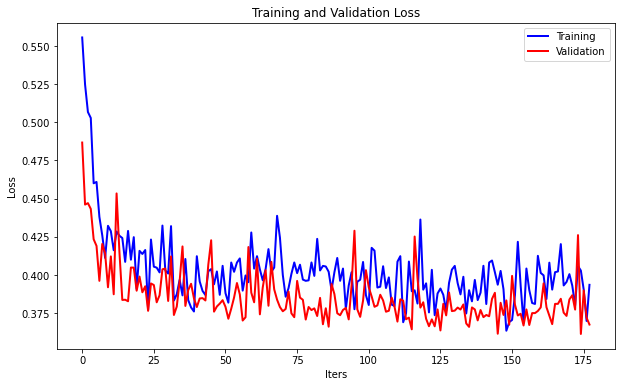

In [15]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=True, fig_name = '/hpc/home/srs108/sentinel_binary_loss')

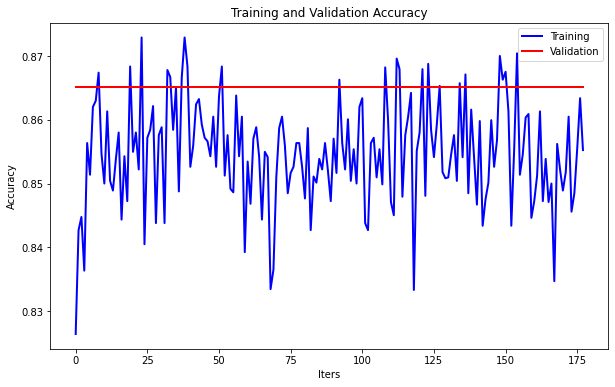

In [16]:
train_val_acc(df['train_acc'], df['val_acc'], len(df['epoch']), save=True , fig_name = '/hpc/home/srs108/sentinel_binary_acc')

## Testing

In [9]:
model = CNN().to(device)
model.load_state_dict(torch.load('sb.pt'))
criterion = nn.BCEWithLogitsLoss().to(device)  

In [11]:
from sklearn.metrics import balanced_accuracy_score

In [13]:
model.eval()
running_loss = 0
running_acc = 0
running_bacc = 0

all_labels_for_auc = []
all_outputs_for_auc = []

all_binary_for_cm = []
all_labels_for_cm = []
all_outputs_for_cm = []

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['planet'].float().to(device)
        y = batch['class_label'].float().to(device) 
        c = batch['ci_avg'].to(device)
        output =  model(x).squeeze(dim=1)
#         print()

        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1

        loss = criterion(output, y)
        running_loss += loss.item()

        all_labels_for_auc.append(y.cpu().detach().numpy())
        all_outputs_for_auc.append(output.cpu().detach().numpy())
        
        all_labels_for_cm.extend(y.cpu().detach().numpy().tolist())  # Append only values
        all_outputs_for_cm.extend(output.cpu().detach().numpy().tolist())  # Append only values
        all_binary_for_cm.extend(output_binary.tolist()) 

        # accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label, output_binary)
        running_acc += acc
        bacc = balanced_accuracy_score(label, output_binary)
        running_bacc += bacc
       
#         bloom_image_plotting(batch, output_binary,y,c)
        torch.cuda.empty_cache()
# AUC
all_labels_for_auc = np.concatenate(all_labels_for_auc)
all_outputs_for_auc = np.concatenate(all_outputs_for_auc)
auc = roc_auc_score(all_labels_for_auc, all_outputs_for_auc)
fpr, tpr, thresholds = roc_curve(all_labels_for_auc, all_outputs_for_auc)

75it [05:45,  4.60s/it]


In [19]:
rs = {'tpr':tpr,'fpr':fpr, 'auc':auc}

In [20]:
df = pd.DataFrame(rs)
df.to_csv('/hpc/home/srs108/abemarle/planet/rs.csv', index=False)

In [14]:
def plot_roc_curve(fpr, tpr, auc, save=False):
    fig, ax = plt.subplots(1,1)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize = 14)
    ax.set_ylabel('True Positive Rate', fontsize = 14)
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
    plt.show()
    if save ==True:
        fig.savefig('ROC' + '.png', transparent=False, facecolor = 'white')

0.5411772060536829
Testing Accuracy 0.6875
Testing Loss 10.158459092278475


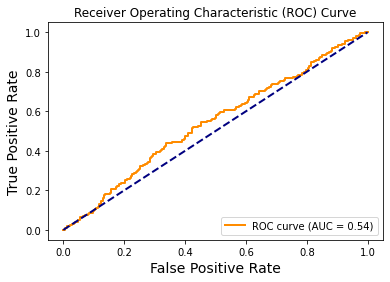

In [15]:
print(auc)

print('Testing Accuracy',running_acc/len(test_loader))
print('Testing Loss',running_loss/len(test_loader))

plot_roc_curve(fpr, tpr, auc, save=False)

In [30]:
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)

plt.figure(figsize=(6, 4))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['no bloom', 'bloom'],
            yticklabels=['no bloom', 'bloom'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight',facecolor='white')  # Adjust dpi and bbox_inches as needed
plt.close() 

In [21]:
running_bacc/len(test_loader)

0.559997890997891

<Axes: >

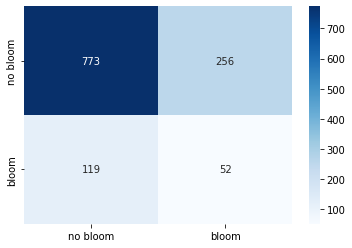

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)
sns.heatmap(cm,annot=True,cmap='Blues', fmt='g',xticklabels=['no bloom', 'bloom'], 
            yticklabels=['no bloom', 'bloom'])
